In [ ]:
import numpy as np
import random
import tensorflow as tf

seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [ ]:
#load data
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_valid, y_valid) = cifar10.load_data()


In [ ]:
#preprocess - normalize + reshape

x_train = x_train.astype("float32") / 255.0
x_valid = x_valid.astype("float32") / 255.0

y_train = y_train.reshape(-1,)
y_valid = y_valid.reshape(-1,)


In [ ]:
print(x_train.shape)
print(y_train.shape)
print(x_valid.shape)
print(y_valid.shape)


(50000, 32, 32, 3)
(50000,)
(10000, 32, 32, 3)
(10000,)


In [ ]:
import numpy as np
print(np.unique(y_train))


[0 1 2 3 4 5 6 7 8 9]


In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


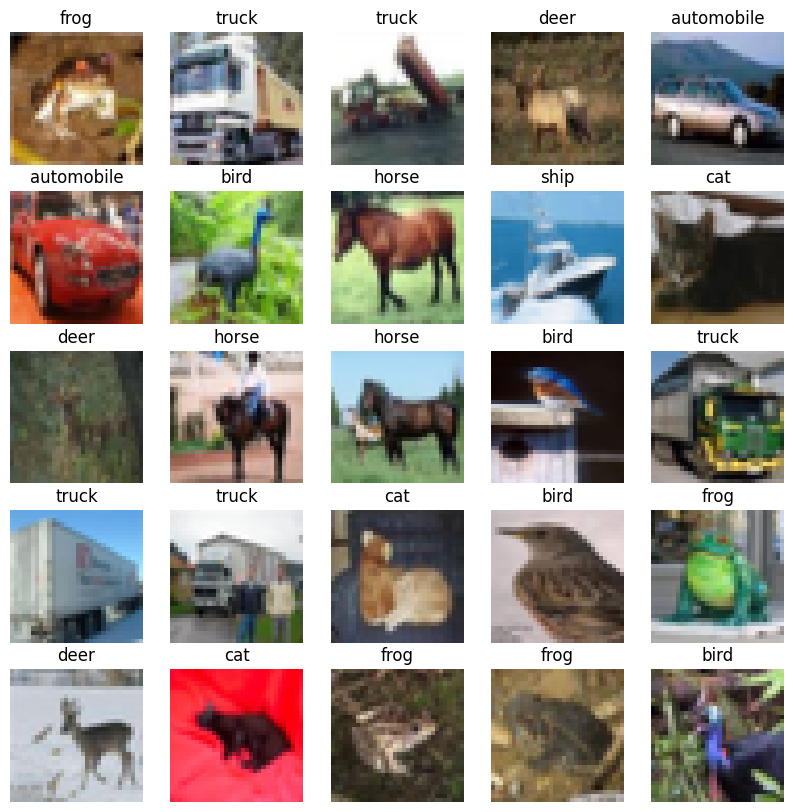

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()


In [ ]:
#baseline CNN model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Rescaling, Conv2D, MaxPooling2D, Flatten, Dense

def build_base_cnn():
  model = Sequential([
      Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
      MaxPooling2D((2, 2)),
      Conv2D(64, (3, 3), activation='relu'),
      MaxPooling2D((2, 2)),
      Flatten(),
      Dense(128, activation='relu'),
      Dense(10, activation='softmax')
  ])

  return model

In [ ]:
#compile base_cnn model

model_1 = build_base_cnn()

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,218 (1.61 MB)

 Trainable params: 422,218 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#baseline cnn model_1
history_1 = model_1.fit(
    x_train,
    y_train,
    validation_data=(x_valid, y_valid),
    epochs=15
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.9046 - loss: 0.2682 - val_accuracy: 0.6684 - val_loss: 1.5469
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.9165 - loss: 0.2329 - val_accuracy: 0.6701 - val_loss: 1.6635
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 56ms/step - accuracy: 0.9251 - loss: 0.2087 - val_accuracy: 0.6768 - val_loss: 1.7572
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.9359 - loss: 0.1773 - val_accuracy: 0.6813 - val_loss: 1.8109
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.9430 - loss: 0.1582 - val_accuracy: 0.6758 - val_loss: 2.0014
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.9464 - loss: 0.1505 - val_accuracy: 0.6717 - val_loss: 2.0760
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.9532 - loss: 0.1321 - val_accuracy: 0.6770 - val_loss: 2.1718
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.9547 

In [ ]:
import numpy as np

np.save('history_1.npy', history_1.history)



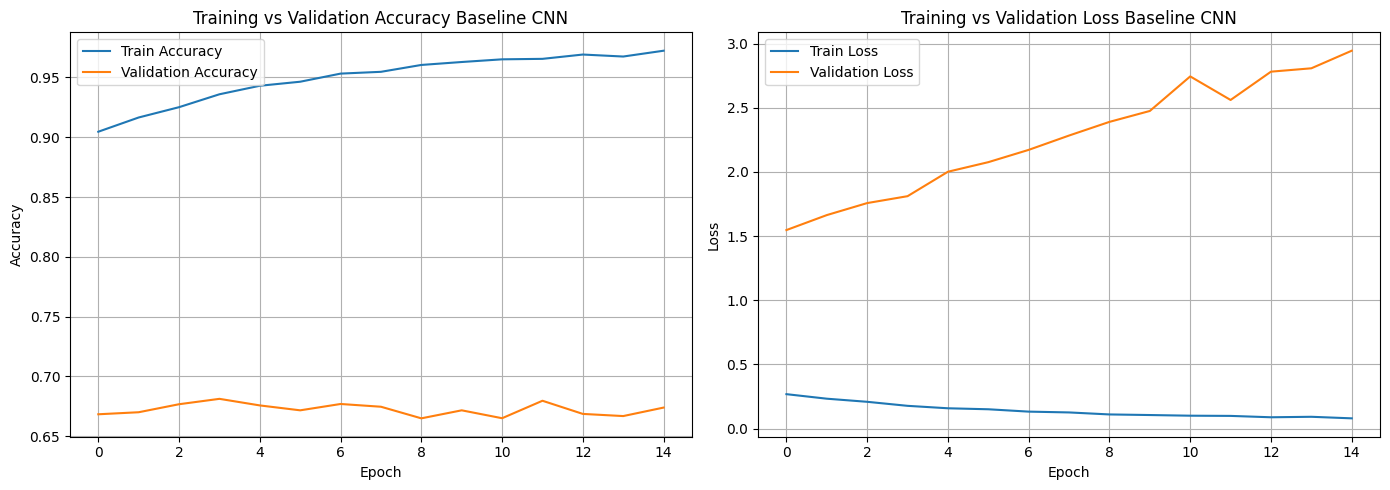

In [ ]:
#base cnn accuracy / loss curve - traingin vs validation
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy Baseline CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss Baseline CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


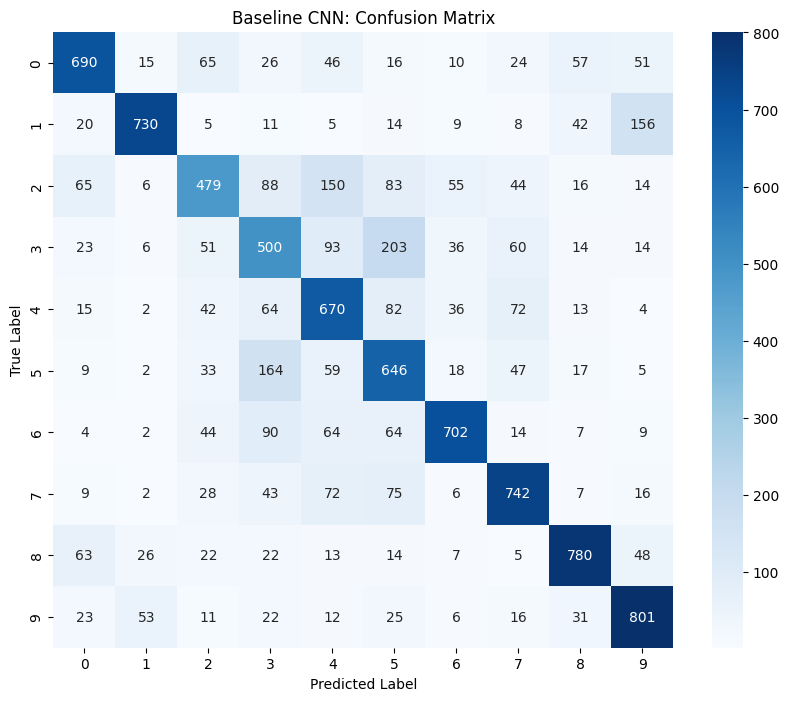

In [ ]:
#confusion matrix for model 1
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Predict on validation set
y_pred_probs_m1 = model_1.predict(x_valid)
y_pred_m1 = tf.argmax(y_pred_probs_m1, axis=1).numpy()

# True labels
y_true_m1 = y_valid

# Build confusion matrix
cm = confusion_matrix(y_true_m1, y_pred_m1)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline CNN: Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
#classification report for model1

from sklearn.metrics import classification_report
print(classification_report(y_true_m1, y_pred_m1))


              precision    recall  f1-score   support

           0       0.75      0.69      0.72      1000
           1       0.86      0.73      0.79      1000
           2       0.61      0.48      0.54      1000
           3       0.49      0.50      0.49      1000
           4       0.57      0.67      0.61      1000
           5       0.53      0.65      0.58      1000
           6       0.79      0.70      0.74      1000
           7       0.72      0.74      0.73      1000
           8       0.79      0.78      0.79      1000
           9       0.72      0.80      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.68     10000
weighted avg       0.68      0.67      0.68     10000



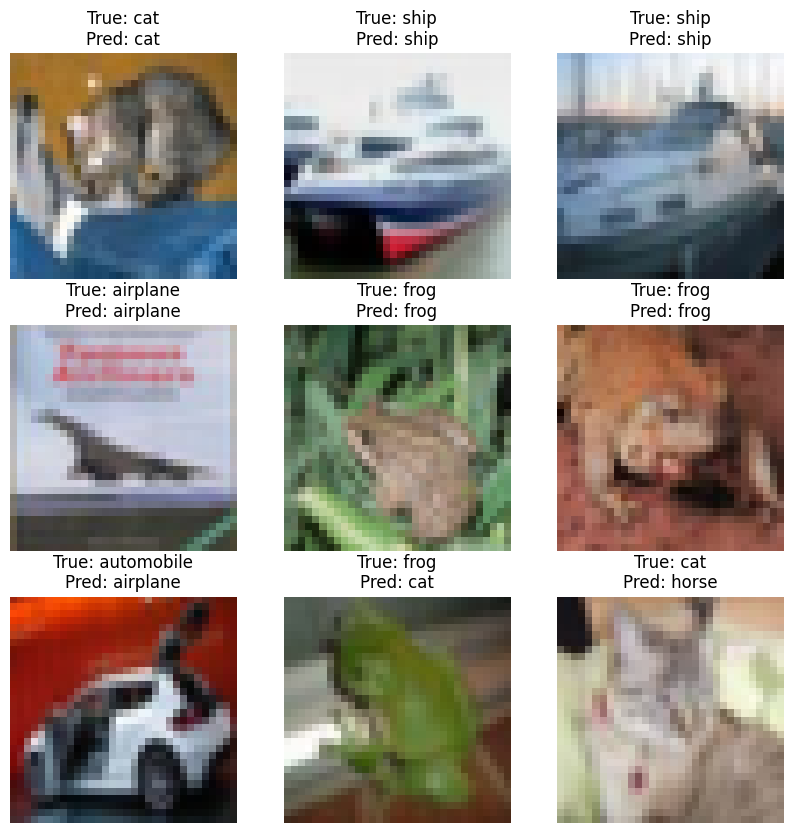

In [ ]:
#sample predictions for model 1

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_valid[i])
    plt.title(f"True: {class_names[y_true_m1[i]]}\nPred: {class_names[y_pred_m1[i]]}")
    plt.axis('off')
plt.show()


In [ ]:
#cnn model with reg
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal



def build_model_2(lambda_value=1e-4, dropout_rate=0.3):
  model = Sequential()

  model.add(Conv2D(32, (3, 3), activation='relu',
                   kernel_initializer=HeNormal(),
                   kernel_regularizer=l2(lambda_value),
                   input_shape=(32,32,3)))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))

  model.add(Conv2D(64, (3, 3), activation='relu',
                   kernel_initializer=HeNormal(),
                   kernel_regularizer=l2(lambda_value)))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))

  model.add(Conv2D(128, (3, 3), padding='same', activation='relu',
                   kernel_initializer=HeNormal(),
                   kernel_regularizer=l2(lambda_value)))
  model.add(BatchNormalization())
  model.add(MaxPooling2D((2,2)))

  model.add(GlobalAveragePooling2D())


  model.add(Dense(128, activation='relu',
                  kernel_initializer=HeNormal(),
                  kernel_regularizer=l2(lambda_value)))
  model.add(BatchNormalization())
  model.add(Dropout(dropout_rate))


  model.add(Dense(10, activation='softmax'))

  return model

In [ ]:
model_2 = build_model_2()

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_43 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,458 (439.29 KB)

 Trainable params: 111,754 (436.54 KB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
#baseline cnn with reg model_2
history_2 = model_2.fit(
    x_train,
    y_train,
    validation_data=(x_valid, y_valid),
    epochs=15
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms/step - accuracy: 0.4764 - loss: 1.5446 - val_accuracy: 0.5344 - val_loss: 1.3538
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 85ms/step - accuracy: 0.6202 - loss: 1.1597 - val_accuracy: 0.5871 - val_loss: 1.2434
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.6776 - loss: 1.0048 - val_accuracy: 0.6192 - val_loss: 1.1766
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - accuracy: 0.7196 - loss: 0.9004 - val_accuracy: 0.6486 - val_loss: 1.1275
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.7485 - loss: 0.8238 - val_accuracy: 0.6647 - val_loss: 1.0921
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 88ms/step - accuracy: 0.7727 - loss: 0.7618 - val_accuracy: 0.6672 - val_loss: 1.1372
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 85ms/step - accuracy: 0.7949 - loss: 0.7063 - val_accuracy: 0.6843 - val_loss: 1.1278
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 

In [ ]:
import numpy as np

np.save('history_2.npy', history_2.history)

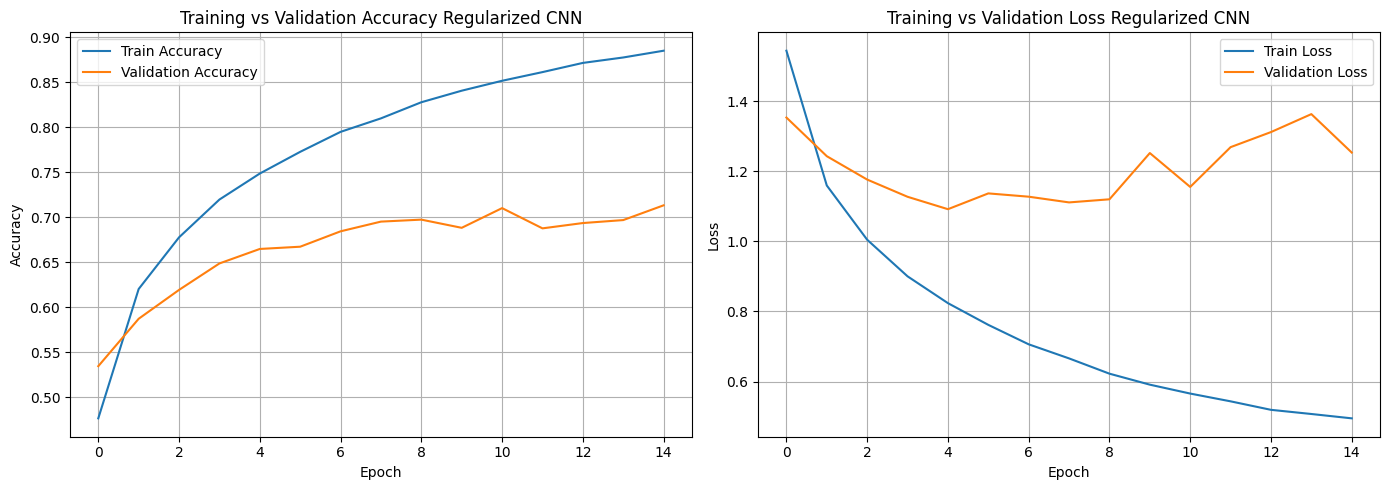

In [ ]:
#cnn reg accuracy / loss curve - traingin vs validation
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Accuracy subplot
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy Regularized CNN')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss subplot
plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss Regularized CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#classification report for model2

from sklearn.metrics import classification_report
print(classification_report(y_true_m2, y_pred_m2))

              precision    recall  f1-score   support

           0       0.71      0.77      0.74      1000
           1       0.80      0.86      0.83      1000
           2       0.61      0.58      0.59      1000
           3       0.46      0.63      0.53      1000
           4       0.76      0.57      0.65      1000
           5       0.59      0.67      0.63      1000
           6       0.90      0.52      0.66      1000
           7       0.71      0.78      0.74      1000
           8       0.84      0.81      0.83      1000
           9       0.82      0.82      0.82      1000

    accuracy                           0.70     10000
   macro avg       0.72      0.70      0.70     10000
weighted avg       0.72      0.70      0.70     10000



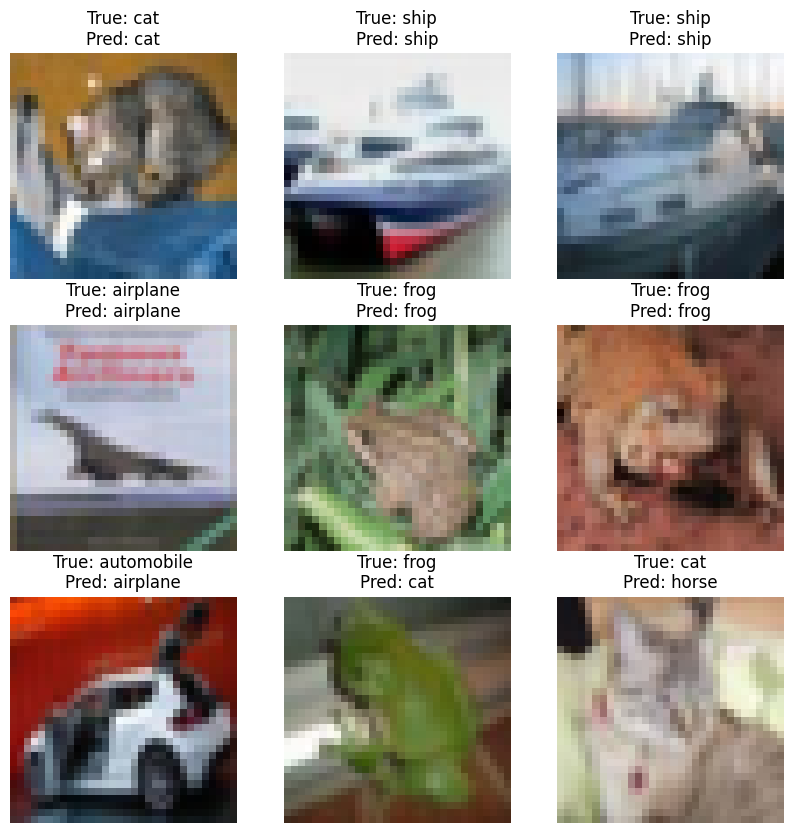

In [ ]:
#sample predictions for model 2

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_valid[i])
    plt.title(f"True: {class_names[y_true_m1[i]]}\nPred: {class_names[y_pred_m1[i]]}")
    plt.axis('off')
plt.show()

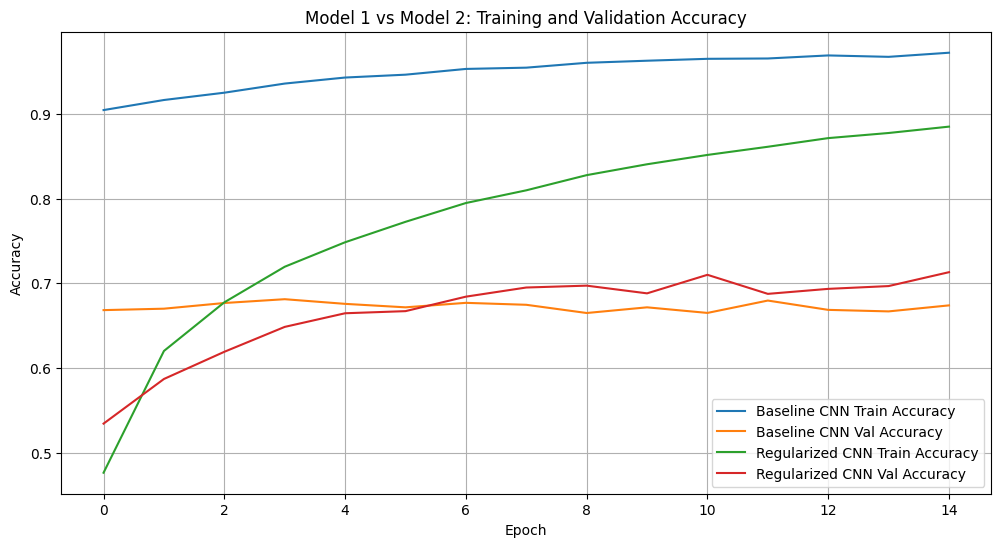

In [ ]:
#comparing loss / accuracy of models 1 and 2
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Accuracy comparison
plt.plot(history_1.history['accuracy'], label='Baseline CNN Train Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Baseline CNN Val Accuracy')

plt.plot(history_2.history['accuracy'], label='Regularized CNN Train Accuracy')
plt.plot(history_2.history['val_accuracy'], label='Regularized CNN Val Accuracy')

plt.title('Model 1 vs Model 2: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


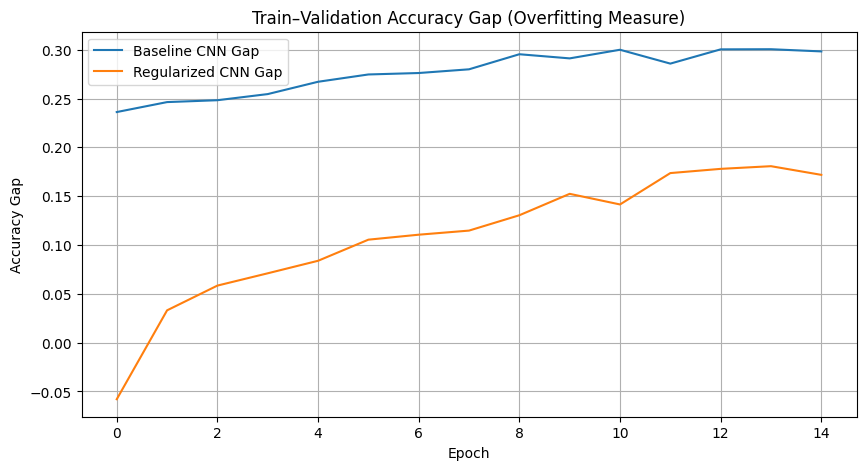

In [ ]:
#train / val gap
import matplotlib.pyplot as plt
import numpy as np

epochs_1 = range(len(history_1.history['accuracy']))
epochs_2 = range(len(history_2.history['accuracy']))

gap_1 = np.array(history_1.history['accuracy']) - np.array(history_1.history['val_accuracy'])
gap_2 = np.array(history_2.history['accuracy']) - np.array(history_2.history['val_accuracy'])

plt.figure(figsize=(10,5))
plt.plot(epochs_1, gap_1, label='Baseline CNN Gap')
plt.plot(epochs_2, gap_2, label='Regularized CNN Gap')
plt.title('Train–Validation Accuracy Gap (Overfitting Measure)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap')
plt.legend()
plt.grid(True)
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


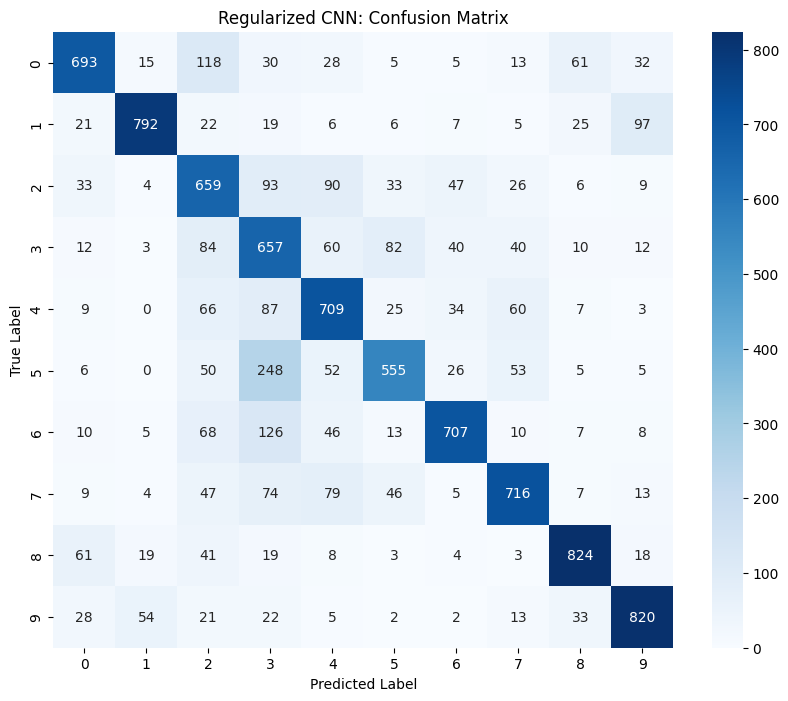

In [ ]:
#confusion matrix for model 2
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Predict on validation set
y_pred_probs_m2 = model_2.predict(x_valid)
y_pred_m2 = tf.argmax(y_pred_probs_m2, axis=1).numpy()

# True labels
y_true_m2 = y_valid

# Build confusion matrix
cm = confusion_matrix(y_true_m2, y_pred_m2)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Regularized CNN: Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


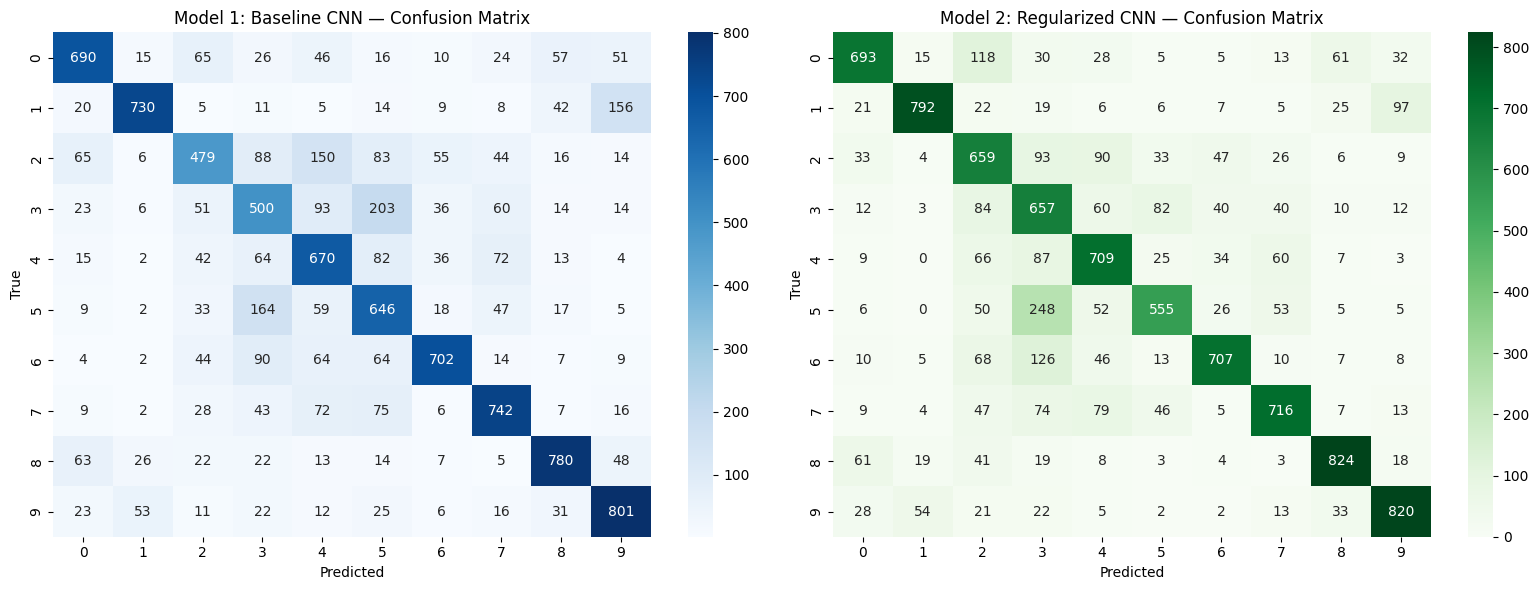

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf

# --- Model 1 predictions ---
y_pred_probs_m1 = model_1.predict(x_valid)
y_pred_m1 = tf.argmax(y_pred_probs_m1, axis=1).numpy()
y_true_m1 = y_valid

cm1 = confusion_matrix(y_true_m1, y_pred_m1)

# --- Model 2 predictions ---
y_pred_probs_m2 = model_2.predict(x_valid)
y_pred_m2 = tf.argmax(y_pred_probs_m2, axis=1).numpy()
y_true_m2 = y_valid

cm2 = confusion_matrix(y_true_m2, y_pred_m2)

# --- Plot side-by-side ---
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title("Model 1: Baseline CNN — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1, 2, 2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title("Model 2: Regularized CNN — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()


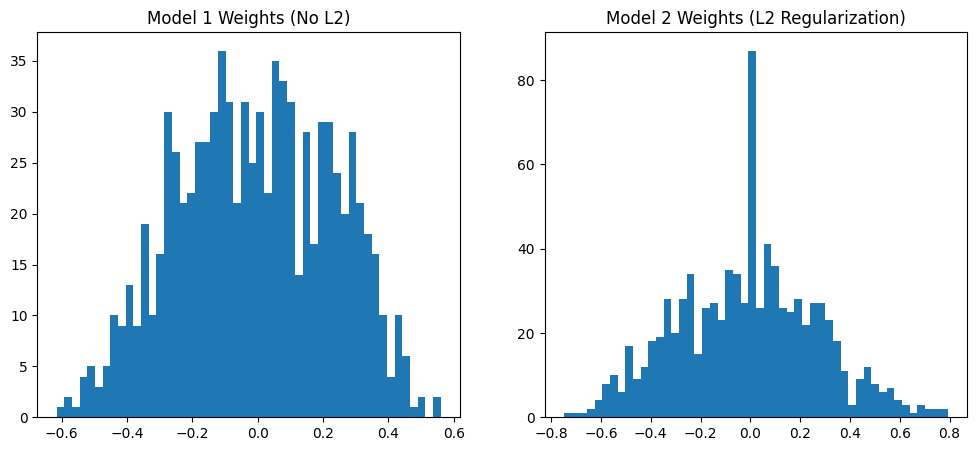

In [ ]:
# L2 weight comparison

w1 = model_1.layers[0].get_weights()[0].flatten()   # Model 1 weights
w2 = model_2.layers[0].get_weights()[0].flatten()   # Model 2 weights (L2)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(w1, bins=50)
plt.title("Model 1 Weights (No L2)")

plt.subplot(1,2,2)
plt.hist(w2, bins=50)
plt.title("Model 2 Weights (L2 Regularization)")

plt.show()


In [ ]:
subset = 2000
x_subset = x_valid[:subset]
y_subset = y_valid[:subset]

# ⭐ Call each model once so Keras defines the input tensor
_ = model_1.predict(x_subset[:1])
_ = model_2.predict(x_subset[:1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


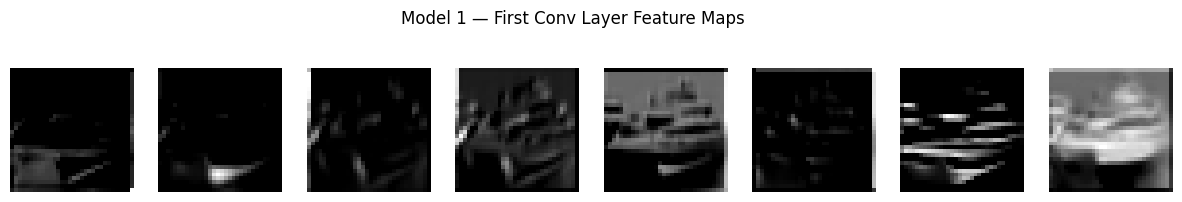

In [ ]:
# Visualization code for Model 1
layer_outputs = [layer.output for layer in model_1.layers if isinstance(layer, layers.Conv2D)]

# ⭐ Use model_1.inputs instead of model_1.input
activation_model_1 = Model(inputs=model_1.inputs, outputs=layer_outputs)

# Use x_valid instead of x_test
sample_img = x_valid[1][np.newaxis, ...]

activations = activation_model_1.predict(sample_img)

first_conv_activation = activations[0]

plt.figure(figsize=(15,2))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(first_conv_activation[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle('Model 1 — First Conv Layer Feature Maps', y=1.1)
plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


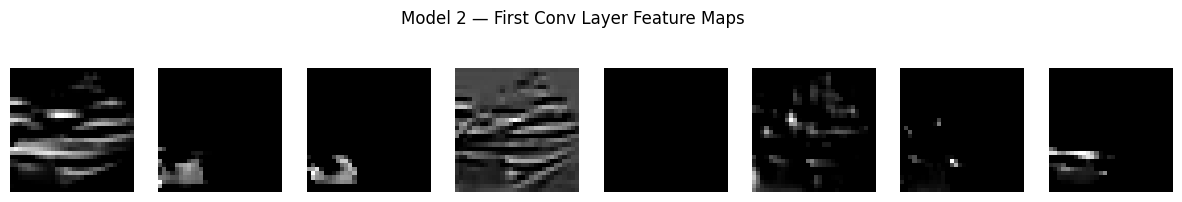

In [ ]:
# Visualization code for Model 2
layer_outputs = [layer.output for layer in model_2.layers if isinstance(layer, layers.Conv2D)]

# ⭐ Use model_2.inputs instead of model_2.input
activation_model_2 = Model(inputs=model_2.inputs, outputs=layer_outputs)

# Use x_valid instead of x_test
sample_img = x_valid[1][np.newaxis, ...]

activations = activation_model_2.predict(sample_img)

first_conv_activation = activations[0]

plt.figure(figsize=(15,2))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(first_conv_activation[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle('Model 2 — First Conv Layer Feature Maps', y=1.1)
plt.show()


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


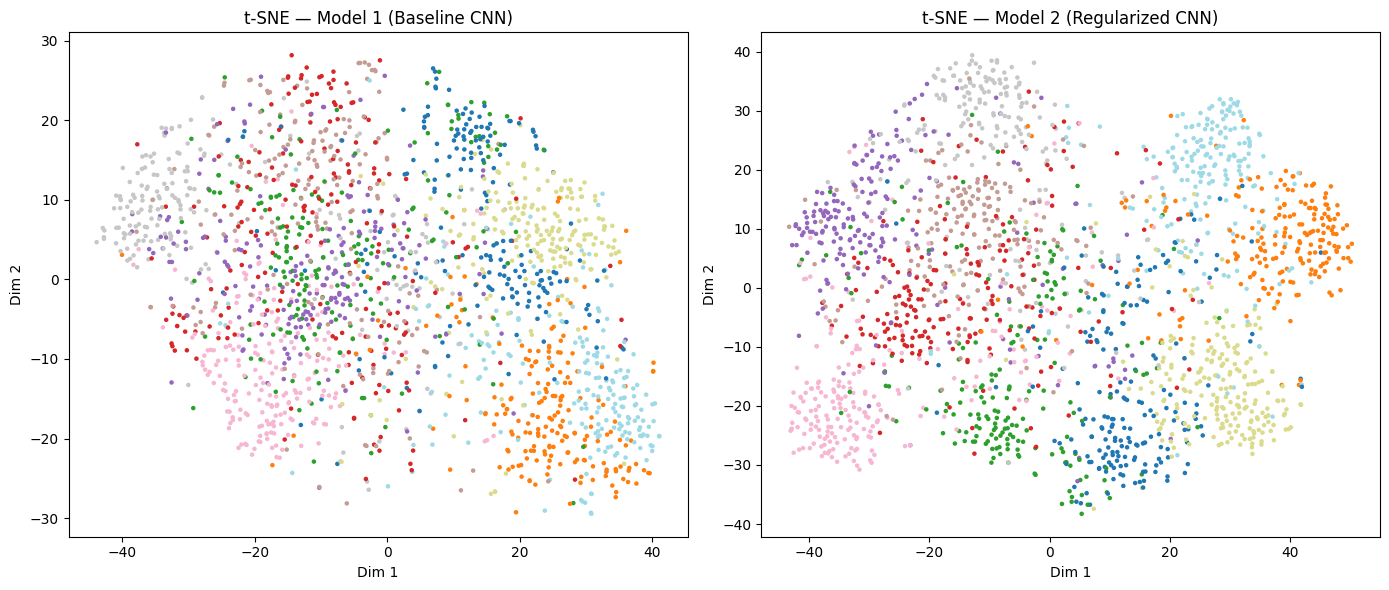

In [ ]:
# tsne for model 1 and 2
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


feature_extractor_m1 = tf.keras.Model(
    inputs=model_1.inputs,
    outputs=model_1.layers[-2].output
)

features_m1 = feature_extractor_m1.predict(x_subset)


feature_extractor_m2 = tf.keras.Model(
    inputs=model_2.inputs,
    outputs=model_2.layers[-2].output
)

features_m2 = feature_extractor_m2.predict(x_subset)


tsne = TSNE(n_components=2, random_state=42)

tsne_m1 = tsne.fit_transform(features_m1)
tsne_m2 = tsne.fit_transform(features_m2)


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(tsne_m1[:,0], tsne_m1[:,1], c=y_subset, cmap='tab20', s=5)
plt.title("t-SNE — Model 1 (Baseline CNN)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(tsne_m2[:,0], tsne_m2[:,1], c=y_subset, cmap='tab20', s=5)
plt.title("t-SNE — Model 2 (Regularized CNN)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.tight_layout()
plt.show()



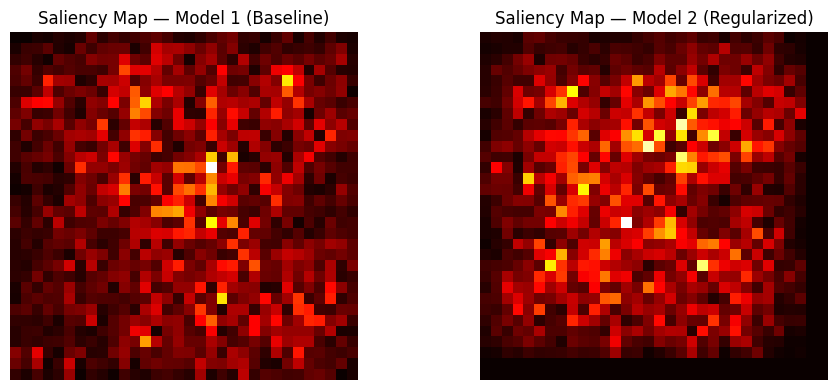

In [ ]:
#model 1 and 2 saliency
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


x_sample_np = x_valid[:1]
x_sample = tf.convert_to_tensor(x_sample_np, dtype=tf.float32)

def compute_saliency(model, x):
    with tf.GradientTape() as tape:
        tape.watch(x)
        preds = model(x)
        top_index = tf.argmax(preds[0])
        top_score = preds[0, top_index]

    grads = tape.gradient(top_score, x)
    grads = tf.reduce_max(tf.abs(grads), axis=-1)[0]   # reduce across channels
    return grads.numpy()


saliency_m1 = compute_saliency(model_1, x_sample)
saliency_m2 = compute_saliency(model_2, x_sample)


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(saliency_m1, cmap='hot')
plt.title("Saliency Map — Model 1 (Baseline)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(saliency_m2, cmap='hot')
plt.title("Saliency Map — Model 2 (Regularized)")
plt.axis('off')

plt.tight_layout()
plt.show()

